# Phase 4: Evaluation Report
## Trust-Weighted Multi-Agent Co-Learning

This notebook loads the ablation outputs and produces all plots and statistical tests for the three research questions:

- **RQ1**: Does trust converge? (entropy trajectory)
- **RQ2**: Does S2 outperform S1? (Sharpe ratio comparison)
- **RQ3**: Does asymmetric trust emerge and correlate with performance?

Run `scripts/run_ablations.py` before executing this notebook.

In [1]:
import sys
sys.path.insert(0, 'src')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as scipy_stats

from twmacl.baselines import markowitz_sharpe_analytical
from twmacl.config import load_experiment_config

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

ABLATIONS_ROOT = Path('outputs/ablations')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Load market config for analytical Markowitz Sharpe
cfg = load_experiment_config('configs/phase2.yaml')
mu  = np.asarray(cfg.market.mu)
cov = np.asarray(cfg.market.cov)
steps_per_year = cfg.learning.steps_per_year
MW_SHARPE_PER_STEP = markowitz_sharpe_analytical(mu, cov)
MW_SHARPE_ANNUALIZED = MW_SHARPE_PER_STEP * np.sqrt(steps_per_year)

print(f'Markowitz analytical Sharpe (per step):   {MW_SHARPE_PER_STEP:.4f}')
print(f'Markowitz analytical Sharpe (annualized): {MW_SHARPE_ANNUALIZED:.4f}')
print(f'Ablation root: {ABLATIONS_ROOT.resolve()}')

Markowitz analytical Sharpe (per step):   0.0312
Markowitz analytical Sharpe (annualized): 0.4945
Ablation root: /root/MFF/Agent-Co-Learning/outputs/ablations


In [2]:
# ============================================================
# Data loading helpers
# ============================================================

def load_all_run_summaries(root: Path) -> pd.DataFrame:
    dfs = []
    for f in root.glob('**/runs/*_summary.parquet'):
        df = pd.read_parquet(f)
        df['experiment_name'] = f.parts[-3]
        dfs.append(df)
    if not dfs:
        raise FileNotFoundError(f'No run summaries found under {root}. Run scripts/run_ablations.py first.')
    return pd.concat(dfs, ignore_index=True)


def load_all_train_steps(root: Path) -> pd.DataFrame:
    dfs = []
    for f in root.glob('**/train/steps/*_steps.parquet'):
        df = pd.read_parquet(f)
        df['experiment_name'] = f.parts[-4]
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def parse_ablation_name(name: str) -> dict:
    if name == 'phase2_baseline':
        return {'strategy': 'S1', 'predictor': 'baseline', 'beta': 0.0, 'label': 'S1 Baseline'}
    try:
        pred = name.split('_beta_')[0].replace('pred_', '')
        beta = float(name.split('_beta_')[1].replace('p', '.'))
        label = f'S2 {pred} β={beta}'
        return {'strategy': 'S2', 'predictor': pred, 'beta': beta, 'label': label}
    except Exception:
        return {'strategy': '?', 'predictor': name, 'beta': 0.0, 'label': name}


runs = load_all_run_summaries(ABLATIONS_ROOT)
meta = runs['experiment_name'].apply(parse_ablation_name).apply(pd.Series)
runs = pd.concat([runs, meta], axis=1)

# Pick last eval episode Sharpe column as primary metric
eval_sharpe_cols = sorted([c for c in runs.columns if 'eval_final_sharpe_mean_episode' in c])
train_sharpe_cols = sorted([c for c in runs.columns if 'train_final_sharpe_mean_episode' in c])
SHARPE_COL = eval_sharpe_cols[-1]

print(f'Experiments loaded: {runs["experiment_name"].nunique()}')
print(f'Total runs (seeds x experiments): {len(runs)}')
print(f'Primary Sharpe column: {SHARPE_COL}')
print(f'\nPer-experiment mean Sharpe:')
print(runs.groupby(['strategy', 'predictor', 'beta'])[SHARPE_COL].agg(['mean','std']).round(4))

Experiments loaded: 9
Total runs (seeds x experiments): 45
Primary Sharpe column: eval_final_sharpe_mean_episode_2

Per-experiment mean Sharpe:
                                mean     std
strategy predictor      beta                
S1       baseline       0.0   0.0046  0.0530
S2       moving_average 0.1   0.0098  0.0585
                        0.2   0.0137  0.0627
                        0.5   0.0203  0.0751
                        0.8   0.0204  0.0717
         noisy_oracle   0.1   0.0098  0.0585
                        0.2   0.0137  0.0627
                        0.5   0.0203  0.0750
                        0.8   0.0203  0.0716


---
## RQ1: Does Trust Converge?

We expect trust entropy to decrease over the episode as agents accumulate observation history. Convergence is declared when the rolling entropy slope stays below the threshold for `convergence_persistence` consecutive steps.

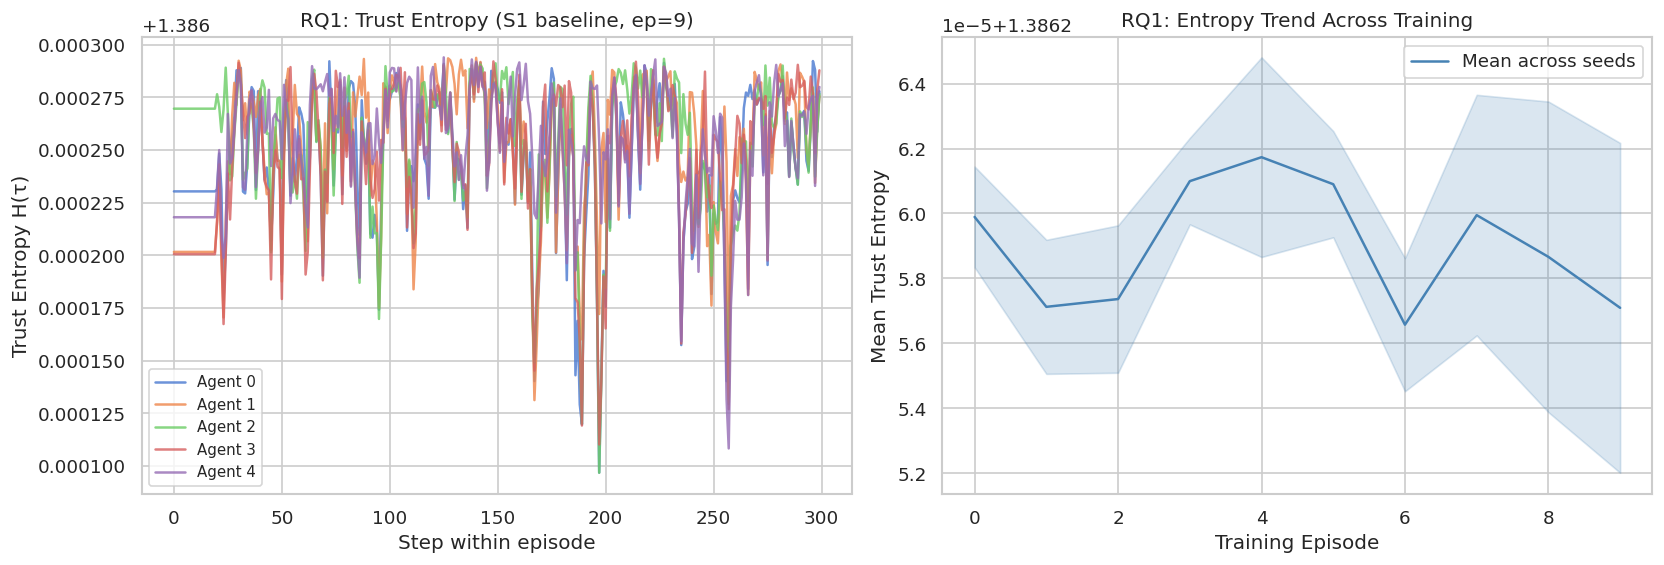

Final mean entropy: 1.3863 (lower = more concentrated trust)


In [3]:
# Load training step data for the S1 baseline (one seed for illustration)
baseline_dir = ABLATIONS_ROOT / 'phase2_baseline'
seed_files = sorted((baseline_dir / 'train' / 'steps').glob('*_steps.parquet'))

if not seed_files:
    print('No step files found — run ablations first')
else:
    # Illustrate with the first seed; aggregate over all seeds
    df_one = pd.read_parquet(seed_files[0])
    num_agents = len([c for c in df_one.columns if c.startswith('entropy_') and 'slope' not in c])
    entropy_cols = [f'entropy_{i}' for i in range(num_agents)]

    # Plot entropy trajectory for the last training episode (most-learned)
    last_ep = df_one['episode'].max()
    df_ep = df_one[df_one['episode'] == last_ep]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: entropy over steps (one episode)
    ax = axes[0]
    for i, col in enumerate(entropy_cols):
        ax.plot(df_ep['step'], df_ep[col], label=f'Agent {i}', alpha=0.8)
    ax.set_xlabel('Step within episode')
    ax.set_ylabel('Trust Entropy H(τ)')
    ax.set_title(f'RQ1: Trust Entropy (S1 baseline, ep={last_ep})')
    ax.legend(fontsize=9)

    # Right: mean entropy per episode (convergence trend)
    ax2 = axes[1]
    all_seeds_entropy = []
    for sf in seed_files:
        df_s = pd.read_parquet(sf)
        ep_entropy = df_s.groupby('episode')[entropy_cols].mean().mean(axis=1)
        all_seeds_entropy.append(ep_entropy)
    entropy_across_seeds = pd.concat(all_seeds_entropy, axis=1)
    mean_ent = entropy_across_seeds.mean(axis=1)
    std_ent  = entropy_across_seeds.std(axis=1)
    episodes = mean_ent.index
    ax2.plot(episodes, mean_ent, color='steelblue', label='Mean across seeds')
    ax2.fill_between(episodes, mean_ent - std_ent, mean_ent + std_ent, alpha=0.2, color='steelblue')
    ax2.set_xlabel('Training Episode')
    ax2.set_ylabel('Mean Trust Entropy')
    ax2.set_title('RQ1: Entropy Trend Across Training')
    ax2.legend()

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'rq1_trust_entropy.png', dpi=150)
    fig.savefig(FIGURES_DIR / 'rq1_trust_entropy.pdf')
    plt.show()
    print(f'Final mean entropy: {mean_ent.iloc[-1]:.4f} (lower = more concentrated trust)')

---
## RQ2: Does S2 Outperform S1?

Paired t-tests compare S1 baseline Sharpe vs each S2 configuration across the same seeds.

In [4]:
baseline = runs[runs['experiment_name'] == 'phase2_baseline'].copy()
ablations = runs[runs['experiment_name'] != 'phase2_baseline'].copy()

print('=== RQ2: S1 Baseline Sharpe ===')
print(f'  Mean: {baseline[SHARPE_COL].mean():.4f}')
print(f'  Std:  {baseline[SHARPE_COL].std():.4f}')
print(f'  N:    {len(baseline)}')
print()
print('=== S2 Ablation Results ===')
summary = (ablations
    .groupby(['predictor', 'beta'])[SHARPE_COL]
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
print(summary.round(4).to_string(index=False))

print()
print('=== Paired t-tests (S2 vs S1, per seed) ===')
bl_vals = baseline.sort_values('seed')[SHARPE_COL].values
for exp_name, grp in ablations.groupby('experiment_name'):
    s2_vals = grp.sort_values('seed')[SHARPE_COL].values
    min_n = min(len(bl_vals), len(s2_vals))
    if min_n < 2:
        continue
    t, p = scipy_stats.ttest_rel(s2_vals[:min_n], bl_vals[:min_n])
    delta = s2_vals[:min_n].mean() - bl_vals[:min_n].mean()
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    print(f'  {exp_name:45s}  Δ={delta:+.4f}  t={t:+.3f}  p={p:.3f} {sig}')

=== RQ2: S1 Baseline Sharpe ===
  Mean: 0.0046
  Std:  0.0530
  N:    5

=== S2 Ablation Results ===
     predictor  beta   mean    std  count
moving_average   0.8 0.0204 0.0717      5
  noisy_oracle   0.8 0.0203 0.0716      5
moving_average   0.5 0.0203 0.0751      5
  noisy_oracle   0.5 0.0203 0.0750      5
moving_average   0.2 0.0137 0.0627      5
  noisy_oracle   0.2 0.0137 0.0627      5
moving_average   0.1 0.0098 0.0585      5
  noisy_oracle   0.1 0.0098 0.0585      5

=== Paired t-tests (S2 vs S1, per seed) ===
  pred_moving_average_beta_0p1                   Δ=+0.0052  t=+1.797  p=0.147 
  pred_moving_average_beta_0p2                   Δ=+0.0091  t=+1.740  p=0.157 
  pred_moving_average_beta_0p5                   Δ=+0.0157  t=+1.287  p=0.267 
  pred_moving_average_beta_0p8                   Δ=+0.0159  t=+1.419  p=0.229 
  pred_noisy_oracle_beta_0p1                     Δ=+0.0052  t=+1.798  p=0.147 
  pred_noisy_oracle_beta_0p2                     Δ=+0.0091  t=+1.740  p=0.157 
  

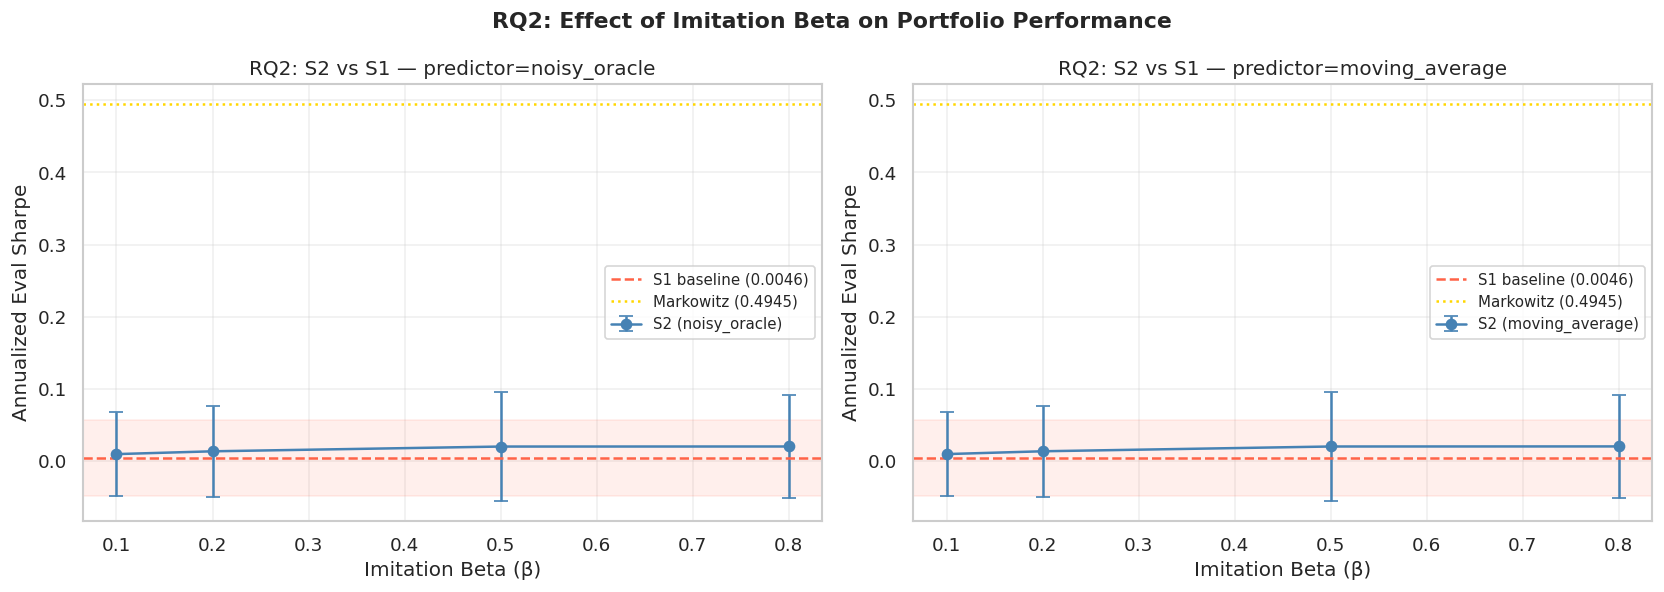

In [5]:
# --- Plot: Sharpe vs Beta ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred in zip(axes, ablations['predictor'].unique()):
    sub = ablations[ablations['predictor'] == pred]
    betas_summary = sub.groupby('beta')[SHARPE_COL].agg(['mean','std']).reset_index()
    bl_mean = baseline[SHARPE_COL].mean()
    bl_std  = baseline[SHARPE_COL].std()

    ax.errorbar(betas_summary['beta'], betas_summary['mean'],
                yerr=betas_summary['std'], fmt='o-', capsize=4,
                color='steelblue', label=f'S2 ({pred})')
    ax.axhline(bl_mean, color='tomato', linestyle='--', linewidth=1.5,
               label=f'S1 baseline ({bl_mean:.4f})')
    ax.axhspan(bl_mean - bl_std, bl_mean + bl_std, alpha=0.1, color='tomato')
    ax.axhline(MW_SHARPE_ANNUALIZED, color='gold', linestyle=':', linewidth=1.5,
               label=f'Markowitz ({MW_SHARPE_ANNUALIZED:.4f})')
    ax.set_xlabel('Imitation Beta (β)')
    ax.set_ylabel('Annualized Eval Sharpe')
    ax.set_title(f'RQ2: S2 vs S1 — predictor={pred}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('RQ2: Effect of Imitation Beta on Portfolio Performance', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'rq2_sharpe_vs_beta.png', dpi=150)
fig.savefig(FIGURES_DIR / 'rq2_sharpe_vs_beta.pdf')
plt.show()

/tmp/ipykernel_3694/286698931.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='label', y=SHARPE_COL, order=order,


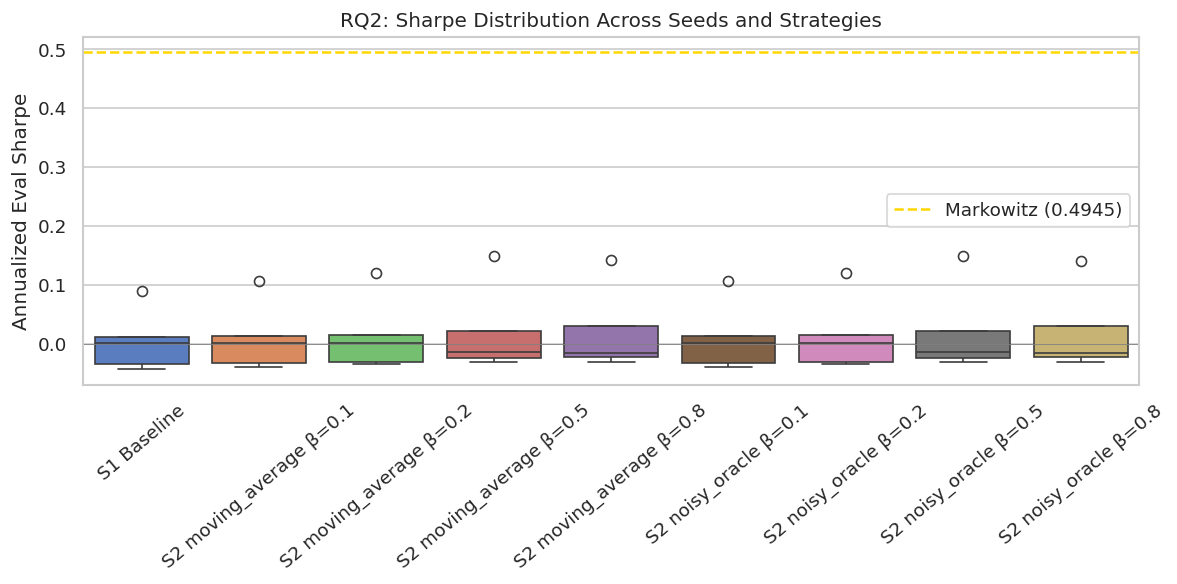

In [6]:
# --- Box plots: distribution comparison ---
plot_data = runs[['label', SHARPE_COL]].copy()
order = (['S1 Baseline'] +
         sorted([l for l in plot_data['label'].unique() if l != 'S1 Baseline']))

fig, ax = plt.subplots(figsize=(max(10, len(order) * 0.8), 5))
sns.boxplot(data=plot_data, x='label', y=SHARPE_COL, order=order,
            palette='muted', ax=ax)
ax.axhline(MW_SHARPE_ANNUALIZED, color='gold', linestyle='--', linewidth=1.5,
           label=f'Markowitz ({MW_SHARPE_ANNUALIZED:.4f})')
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('Annualized Eval Sharpe')
ax.set_title('RQ2: Sharpe Distribution Across Seeds and Strategies')
ax.tick_params(axis='x', rotation=40)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'rq2_sharpe_boxplots.png', dpi=150)
fig.savefig(FIGURES_DIR / 'rq2_sharpe_boxplots.pdf')
plt.show()

---
## RQ3: Trust Asymmetry

Does asymmetric trust emerge (agents trust each other differently), and does it correlate with performance?

/tmp/ipykernel_3694/3159733918.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=runs, x='strategy', y='final_eval_asymmetry',


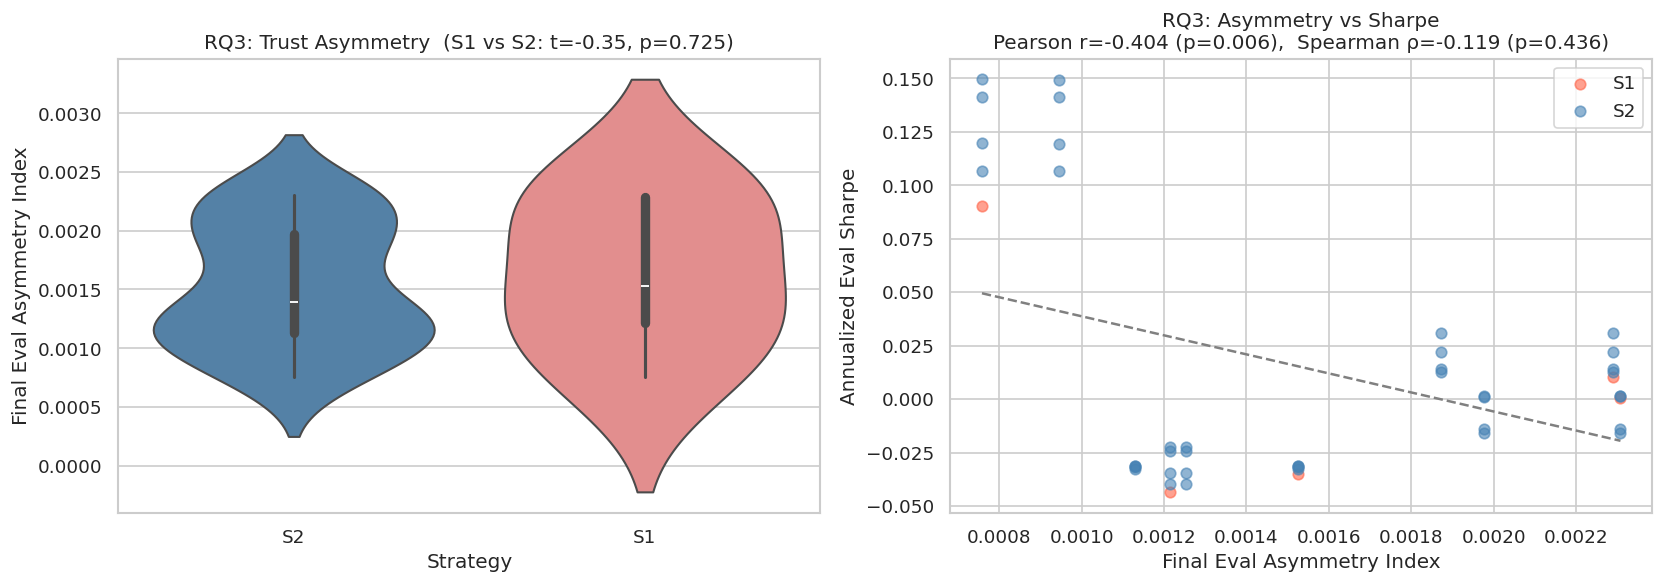

Mean asymmetry S1: 0.0016
Mean asymmetry S2: 0.0015


In [7]:
if 'final_eval_asymmetry' not in runs.columns:
    print('final_eval_asymmetry column not found — data may be from an older run')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: asymmetry distribution per strategy
    ax = axes[0]
    sns.violinplot(data=runs, x='strategy', y='final_eval_asymmetry',
                   palette={'S1': 'lightcoral', 'S2': 'steelblue'}, ax=ax, inner='box')
    ax.set_xlabel('Strategy')
    ax.set_ylabel('Final Eval Asymmetry Index')
    ax.set_title('RQ3: Trust Asymmetry by Strategy')

    t_stat, p_val = scipy_stats.ttest_ind(
        runs[runs['strategy'] == 'S2']['final_eval_asymmetry'].dropna(),
        runs[runs['strategy'] == 'S1']['final_eval_asymmetry'].dropna(),
    )
    ax.set_title(f'RQ3: Trust Asymmetry  (S1 vs S2: t={t_stat:.2f}, p={p_val:.3f})')

    # Right: scatter asymmetry vs Sharpe
    ax2 = axes[1]
    for strategy, grp in runs.groupby('strategy'):
        color = 'tomato' if strategy == 'S1' else 'steelblue'
        ax2.scatter(grp['final_eval_asymmetry'], grp[SHARPE_COL],
                    alpha=0.6, label=strategy, color=color, s=40)

    x = runs['final_eval_asymmetry'].values
    y = runs[SHARPE_COL].values
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 3:
        r_pearson, p_pearson = scipy_stats.pearsonr(x[mask], y[mask])
        r_spearman, p_spearman = scipy_stats.spearmanr(x[mask], y[mask])
        # Regression line
        slope, intercept, *_ = scipy_stats.linregress(x[mask], y[mask])
        x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax2.plot(x_line, slope * x_line + intercept, color='gray', linestyle='--', linewidth=1.5)
        ax2.set_title(
            f'RQ3: Asymmetry vs Sharpe\n'
            f'Pearson r={r_pearson:.3f} (p={p_pearson:.3f}),  '
            f'Spearman ρ={r_spearman:.3f} (p={p_spearman:.3f})'
        )
    else:
        ax2.set_title('RQ3: Asymmetry vs Sharpe')

    ax2.set_xlabel('Final Eval Asymmetry Index')
    ax2.set_ylabel('Annualized Eval Sharpe')
    ax2.legend()

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'rq3_asymmetry.png', dpi=150)
    fig.savefig(FIGURES_DIR / 'rq3_asymmetry.pdf')
    plt.show()

    print(f'Mean asymmetry S1: {runs[runs.strategy=="S1"]["final_eval_asymmetry"].mean():.4f}')
    print(f'Mean asymmetry S2: {runs[runs.strategy=="S2"]["final_eval_asymmetry"].mean():.4f}')

---
## Learning Curve & Markowitz Comparison

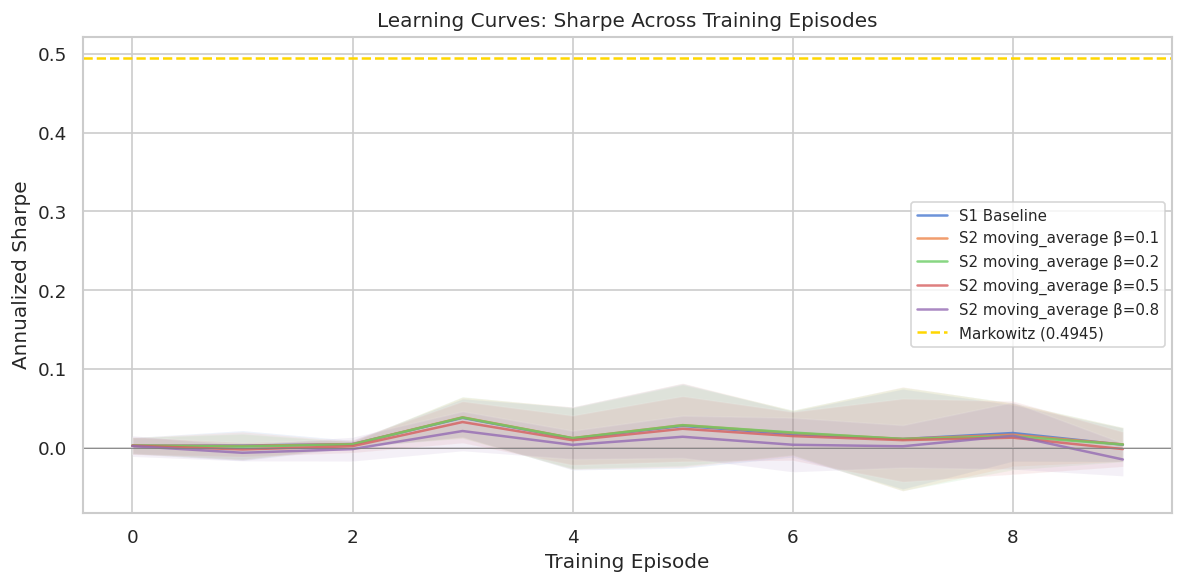

In [8]:
# Learning curve: Sharpe ratio across training episodes
if train_sharpe_cols:
    fig, ax = plt.subplots(figsize=(10, 5))

    for exp_name in ['phase2_baseline'] + sorted(ablations['experiment_name'].unique())[:4]:
        exp_runs = runs[runs['experiment_name'] == exp_name]
        ep_cols = sorted([c for c in train_sharpe_cols
                          if any(c in col for col in exp_runs.columns)])
        # Rebuild from columns that exist
        valid_cols = [c for c in train_sharpe_cols if c in exp_runs.columns]
        if not valid_cols:
            continue
        ep_means = exp_runs[valid_cols].mean()
        ep_stds  = exp_runs[valid_cols].std()
        x = range(len(ep_means))
        meta_info = parse_ablation_name(exp_name)
        ax.plot(x, ep_means.values, label=meta_info['label'], alpha=0.8)
        ax.fill_between(x,
                        ep_means.values - ep_stds.values,
                        ep_means.values + ep_stds.values,
                        alpha=0.1)

    ax.axhline(MW_SHARPE_ANNUALIZED, color='gold', linestyle='--', linewidth=1.5,
               label=f'Markowitz ({MW_SHARPE_ANNUALIZED:.4f})')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Training Episode')
    ax.set_ylabel('Annualized Sharpe')
    ax.set_title('Learning Curves: Sharpe Across Training Episodes')
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'learning_curves.png', dpi=150)
    fig.savefig(FIGURES_DIR / 'learning_curves.pdf')
    plt.show()

In [ ]:
# --- Markowitz ratio bar chart ---
if 'markowitz_annualized_sharpe' in runs.columns:
    # Use simulated Markowitz from data but note it's noisy; print analytical too
    summary_mw = (
        runs.groupby('label').apply(lambda g: pd.Series({
            'sharpe_mean': g[SHARPE_COL].mean(),
            'sharpe_std': g[SHARPE_COL].std(),
            'mw_ratio_mean': (g[SHARPE_COL] / MW_SHARPE_ANNUALIZED).mean(),
            'mw_ratio_std': (g[SHARPE_COL] / MW_SHARPE_ANNUALIZED).std(),
        }))
        .reset_index()
        .sort_values('sharpe_mean', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(summary_mw) * 0.9), 5))
    bars = ax.bar(
        range(len(summary_mw)), summary_mw['mw_ratio_mean'],
        yerr=summary_mw['mw_ratio_std'],
        capsize=4, color='steelblue', alpha=0.8
    )
    ax.axhline(1.0, color='gold', linestyle='--', linewidth=1.5, label='Markowitz = 1.0')
    ax.axhline(0.0, color='gray', linewidth=0.5)
    ax.set_xticks(range(len(summary_mw)))
    ax.set_xticklabels(summary_mw['label'], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Learned Sharpe / Markowitz Analytical Sharpe')
    ax.set_title('Performance Relative to Markowitz Optimum')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'markowitz_ratio.png', dpi=150)
    fig.savefig(FIGURES_DIR / 'markowitz_ratio.pdf')
    plt.show()

print('\nAll figures saved to', FIGURES_DIR.resolve())


All figures saved to /root/MFF/Agent-Co-Learning/figures


: 